In [4]:
from pathlib import Path
import importlib


def _offline_detection_file(filename: str) -> Path:
    """Resolve path whether kernel cwd is repo root or offline-detection/."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd / "offline-detection" / filename, cwd / filename):
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Cwd={cwd}. "
        "Open the project folder or offline-detection/ as the notebook working directory."
    )


MODULE_PATH = _offline_detection_file("main.py")
BASE_DIR = MODULE_PATH.parent

offline_detection = importlib.machinery.SourceFileLoader(
    "offline-detection", str(MODULE_PATH)
).load_module()

In [5]:
import time
import matplotlib.pyplot as plt
import numpy as np

def msg_callback(msg, end=None):
	print(msg)
	time.sleep(1)

	if end is True: print("Done!")

def handle_report(news, **kwargs):
	global predictions
	predictions = news["predictions"]

	bardata = np.unique(predictions, return_counts=True)
	bar = plt.bar(bardata[0], bardata[1])

	plt.bar_label(bar)
	plt.xticks(ticks=[-1, 0, 1, 2], labels=[None, "Normal", "Anomaly", None])
	plt.title("Predictions of the pipeline")
	plt.show()



Starting pipeline execution...



Preprocessing...



Finished preprocessing.



Obtaining model...



Finished modeling.



Predicting...



Predictions created.



Evaluating results...



c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Evaluation Metrics:
accuracy: 0.9982725143693799
recall: 0.0
precision: 0.0


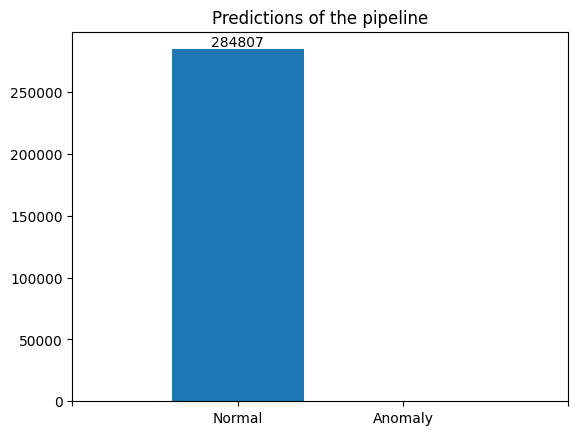



Finished evaluation.



Pipeline execution completed.


Done!


In [6]:
offline_detection.pipeline(
    msg_callback=msg_callback,
    report_callback=handle_report,
    verb=False
)

In [3]:
# Hold-out evaluation (recommended): temporal split, scaler fit on train only.
# Does not require cell 0: resolves main_experiment.py from cwd (repo root or offline-detection/).
import importlib.util
from pathlib import Path

def _offline_detection_file(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd / "offline-detection" / filename, cwd / filename):
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Cwd={cwd}. "
        "Set the notebook kernel working directory to the project or offline-detection/."
    )

_mod_path = _offline_detection_file("main_experiment.py")
_spec = importlib.util.spec_from_file_location("main_experiment", _mod_path)
main_experiment = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(main_experiment)

report = main_experiment.evaluate_pipeline_performance(verb=True)
print("PR-AUC (val):", report["metrics_validation"]["pr_auc"])
print("PR-AUC (test):", report["metrics_test"]["pr_auc"])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




Pipeline performance evaluation (temporal hold-out)...


Split sizes — train: 199364, val: 42721, test: 42722
Positive rate — train: 0.0019, val: 0.0013, test: 0.0012



Fitting model on training split only...


--- Validation set (imbalanced metrics) ---
  pr_auc: 0.03242974361794824
  precision: 0.0
  recall: 0.0
  f1: 0.0
  predicted_anomaly_rate: 0.0018960230331686993
  k_ratio: 0.01
  precision_at_k: 0.04215456674473068
  recall_at_k: 0.32142857142857145

--- Test set (imbalanced metrics) ---
  pr_auc: 0.04607677814964926
  precision: 0.0
  recall: 0.0
  f1: 0.0
  predicted_anomaly_rate: 0.0009128786105519405
  k_ratio: 0.01
  precision_at_k: 0.06557377049180328
  recall_at_k: 0.5384615384615384


Hold-out evaluation finished.


PR-AUC (val): 0.03242974361794824
PR-AUC (test): 0.04607677814964926
